# Рахимьянов Альберт, ЕТ-128, "Бустинг"

## Задание
1. Выполните классификацию набора данных из задания о Байесовской классификации с помощью бустинга, варьируя количество участников ансамбля (от 50 до 100 с шагом 10).
2. Вычислите показатели качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Выполните визуализацию полученных результатов в виде диаграмм. Нанесите на диаграммы соответствующие значения, полученные в заданиях о Байесовской классификации, деревьях решений, бэггинге и случайном лесе.
3. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.

In [1]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загрузка датасета "Рукописные цифры" (1797 объектов изначально) (10 классов)
np.random.seed(42)

X, y = load_digits(return_X_y=True)

X = X + np.random.normal(0, 0.5, X.shape)

print("Размерность данных:", X.shape, np.unique(y))

Размерность данных: (1797, 64) [0 1 2 3 4 5 6 7 8 9]


In [3]:
# Подготавливаем для заполнения результатов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y # Фиксируем разбиение выборок: 80% обучающей и 20% тестовой
)

n_estimators_range = list(range(50, 110, 10)) # Варьируем количество участников ансамбля

metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

In [15]:
# Обучаем модели
learning_rate_values = [0.1, 0.5, 1.0, 1.5]
all_results = {}
for lr in learning_rate_values:
    param_key = f"lr={lr}"
    all_results[param_key] = {
        'n_estimators': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for n in n_estimators_range:
        boost_model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=n,
            learning_rate=lr,
            algorithm=alg,
            random_state=42
        )

        boost_model.fit(X_train, y_train)
        y_pred = boost_model.predict(X_test)

        all_results[param_key]['n_estimators'].append(n)
        all_results[param_key]['accuracy'].append(accuracy_score(y_test, y_pred))
        all_results[param_key]['precision'].append(precision_score(y_test, y_pred, average='macro'))
        all_results[param_key]['recall'].append(recall_score(y_test, y_pred, average='macro'))
        all_results[param_key]['f1'].append(f1_score(y_test, y_pred, average='macro'))

In [17]:
for param_key, metrics in all_results.items():
    print(f"\n{param_key}:")
    print("=" * 70)
    print(f"{'n_estimators':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 70)

    for i, n in enumerate(metrics['n_estimators']):
        print(f"{n:<15} "
              f"{metrics['accuracy'][i]:<12.4f} "
              f"{metrics['precision'][i]:<12.4f} "
              f"{metrics['recall'][i]:<12.4f} "
              f"{metrics['f1'][i]:<12.4f}")


lr=0.1:
n_estimators    Accuracy     Precision    Recall       F1          
----------------------------------------------------------------------
50              0.8889       0.8977       0.8889       0.8881      
60              0.9000       0.9059       0.9000       0.8987      
70              0.9222       0.9280       0.9222       0.9224      
80              0.9222       0.9280       0.9222       0.9224      
90              0.9333       0.9403       0.9333       0.9333      
100             0.9222       0.9260       0.9222       0.9208      

lr=0.5:
n_estimators    Accuracy     Precision    Recall       F1          
----------------------------------------------------------------------
50              0.9000       0.9010       0.9000       0.8961      
60              0.9111       0.9153       0.9111       0.9089      
70              0.9333       0.9357       0.9333       0.9324      
80              0.9333       0.9357       0.9333       0.9324      
90              0.9556  

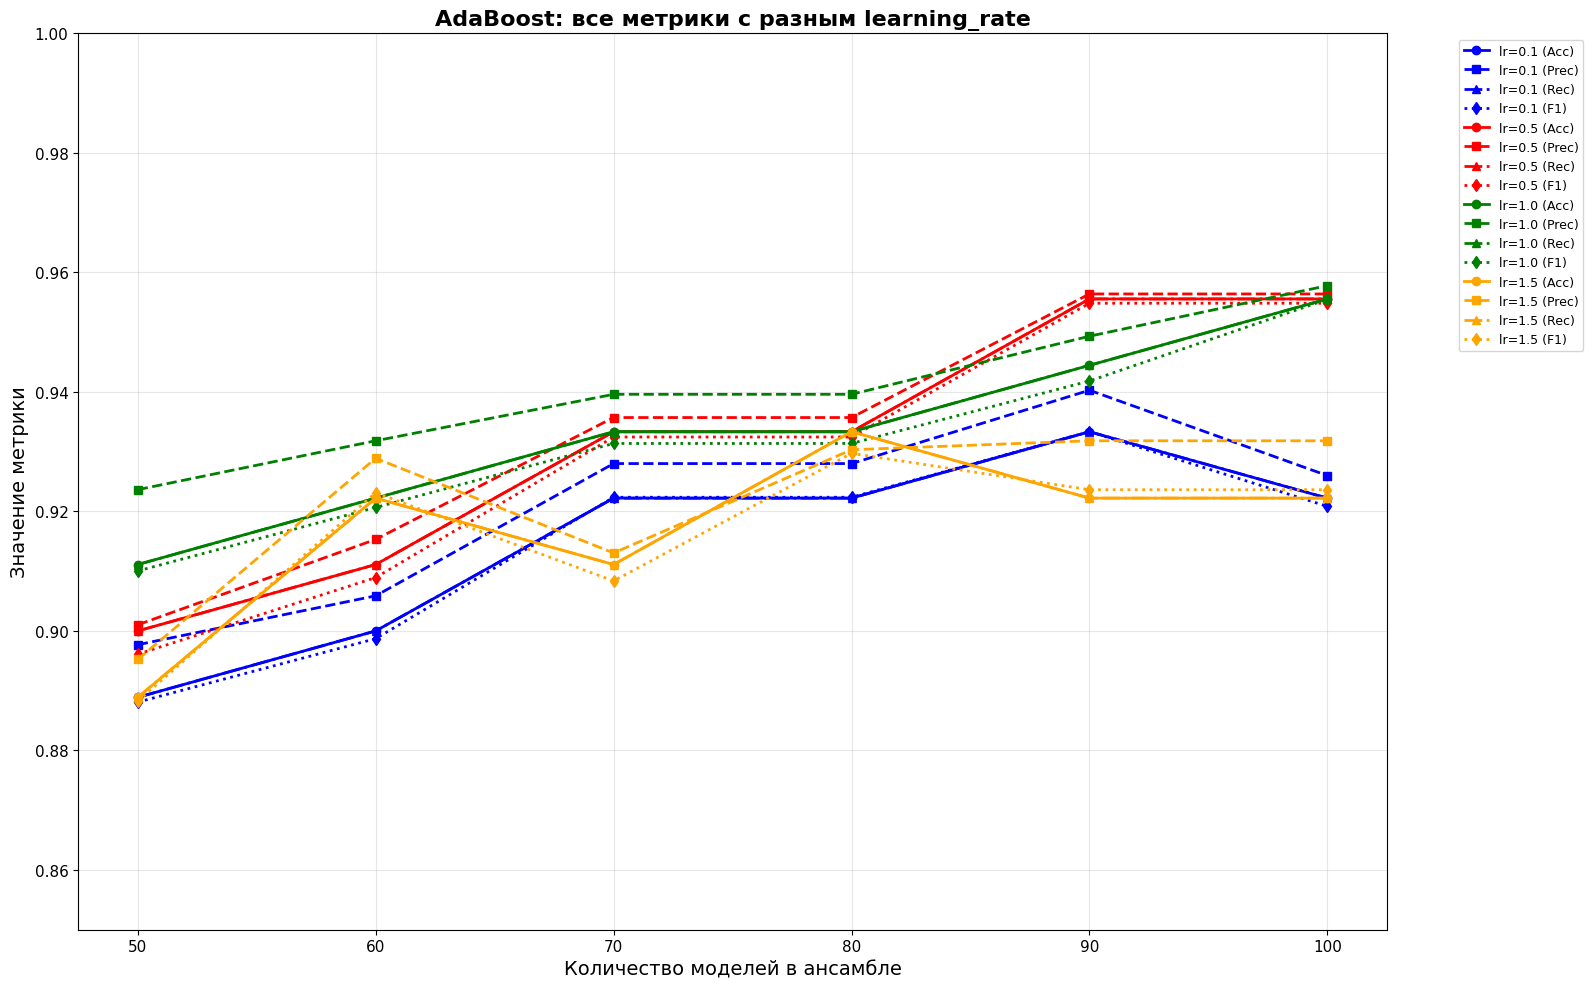

In [19]:
plt.figure(figsize=(16, 10))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd']
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

for idx, (param_key, metrics) in enumerate(all_results.items()):
    color = colors[idx % len(colors)]

    # Accuracy
    plt.plot(metrics['n_estimators'],
            metrics['accuracy'],
            linestyle='-',
            marker='o',
            color=color,
            linewidth=2,
            label=f'{param_key} (Acc)',
            markersize=6)

    # Precision
    plt.plot(metrics['n_estimators'],
            metrics['precision'],
            linestyle='--',
            marker='s',
            color=color,
            linewidth=2,
            label=f'{param_key} (Prec)',
            markersize=6)

    # Recall
    plt.plot(metrics['n_estimators'],
            metrics['recall'],
            linestyle='-.',
            marker='^',
            color=color,
            linewidth=2,
            label=f'{param_key} (Rec)',
            markersize=6)

    # F1
    plt.plot(metrics['n_estimators'],
            metrics['f1'],
            linestyle=':',
            marker='d',
            color=color,
            linewidth=2,
            label=f'{param_key} (F1)',
            markersize=6)

plt.xlabel("Количество моделей в ансамбле", fontsize=14)
plt.ylabel("Значение метрики", fontsize=14)
plt.title("AdaBoost: все метрики с разным learning_rate", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)

plt.xticks(n_estimators_range, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.85, 1)
plt.tight_layout()
plt.show()

In [13]:
# Варьируем размер обучающей выборки
train_ratios = list(range(50, 100, 5))

metrics_rf = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

metrics_bagging = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

metrics_tree = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

metrics_bayes = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

for tr in train_ratios:

    ratio = tr / 100

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, random_state=42, stratify=y
    )

    # Дерево решений (Gini)
    tree_model = DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    )

    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    metrics_tree["accuracy"].append(accuracy_score(y_test, y_pred_tree))
    metrics_tree["precision"].append(precision_score(y_test, y_pred_tree, average="macro"))
    metrics_tree["recall"].append(recall_score(y_test, y_pred_tree, average="macro"))
    metrics_tree["f1"].append(f1_score(y_test, y_pred_tree, average="macro"))


    # Байесовская классификация
    bayes_model = GaussianNB()
    bayes_model.fit(X_train, y_train)
    y_pred_bayes = bayes_model.predict(X_test)

    metrics_bayes["accuracy"].append(accuracy_score(y_test, y_pred_bayes))
    metrics_bayes["precision"].append(precision_score(y_test, y_pred_bayes, average="macro"))
    metrics_bayes["recall"].append(recall_score(y_test, y_pred_bayes, average="macro"))
    metrics_bayes["f1"].append(f1_score(y_test, y_pred_bayes, average="macro"))

# Обучаем модели + беггинг
for n in n_estimators_range:
    # Случайный лес
    rf_model = RandomForestClassifier(
        n_estimators=n,
        criterion="gini",
        max_samples=1.0,
        max_features='log2',
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    metrics_rf["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics_rf["precision"].append(precision_score(y_test, y_pred, average="macro"))
    metrics_rf["recall"].append(recall_score(y_test, y_pred, average="macro"))
    metrics_rf["f1"].append(f1_score(y_test, y_pred, average="macro"))

    # Беггинг
    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        max_samples=1.0,
        max_features=0.5,
        n_estimators=n,
        random_state=42
    )

    bagging_model.fit(X_train, y_train)
    y_pred = bagging_model.predict(X_test)

    metrics_bagging['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics_bagging['precision'].append(precision_score(y_test, y_pred, average='macro'))
    metrics_bagging['recall'].append(recall_score(y_test, y_pred, average='macro'))
    metrics_bagging['f1'].append(f1_score(y_test, y_pred, average='macro'))

    # Бустинг
    boost_model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=n,
        learning_rate=1.0,
        random_state=42
    )

    boost_model.fit(X_train, y_train)
    y_pred = boost_model.predict(X_test)

    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, average="macro"))
    metrics["recall"].append(recall_score(y_test, y_pred, average="macro"))
    metrics["f1"].append(f1_score(y_test, y_pred, average="macro"))

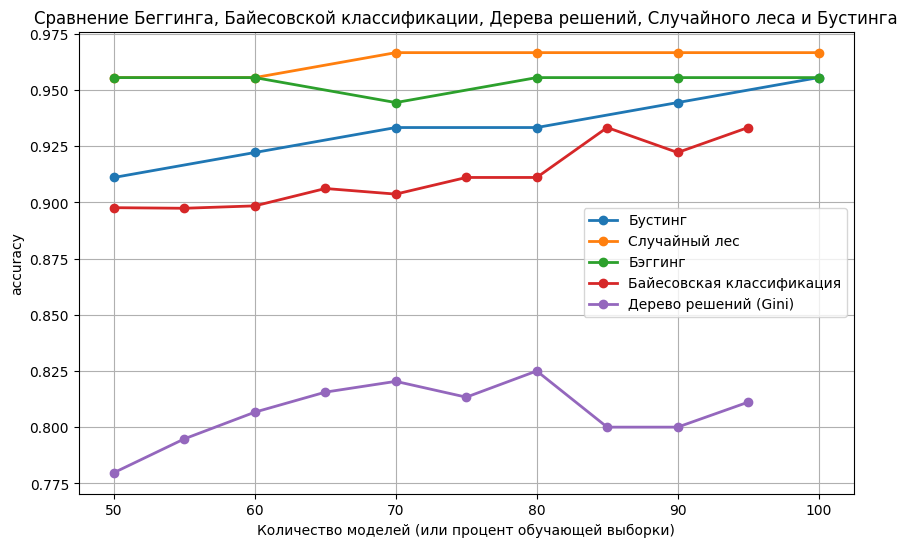

In [16]:
selected_metric = "accuracy"

values = metrics[selected_metric]
rf_values = metrics_rf[selected_metric]
bagging_values = metrics_bagging[selected_metric]
bayes_values = metrics_bayes[selected_metric]
tree_values = metrics_tree[selected_metric]

plt.figure(figsize=(10, 6))

plt.plot(n_estimators_range, values, marker='o', linewidth=2, label="Бустинг")
plt.plot(n_estimators_range, rf_values, marker='o', linewidth=2, label="Случайный лес")
plt.plot(n_estimators_range, bagging_values, marker='o', linewidth=2, label='Бэггинг')
plt.plot(train_ratios, bayes_values, marker='o', linewidth=2, label="Байесовская классификация")
plt.plot(train_ratios, tree_values, marker='o', linewidth=2, label="Дерево решений (Gini)")

plt.xlabel("Количество моделей (или процент обучающей выборки)")
plt.ylabel(selected_metric)
plt.title("Сравнение Беггинга, Байесовской классификации, Дерева решений, Случайного леса и Бустинга")
plt.legend()
plt.grid(True)
plt.show()
